# Lesson 4: Flood Fill and Connected Components

Once we have a binary image (e.g., from thresholding, Lesson 3), a natural next question is: *how many separate blobs are there, and where are they?* Two tools answer this:

- **Flood fill** grows a region from a single seed pixel, spreading to all connected neighbors that share a similar value.
- **Connected component labeling** finds *all* such regions in a binary image at once, labeling each with a unique ID.

In [1]:
# Download the sample images used in this lesson, if not already present
import os, urllib.request

for _f in ['fruit.jpg']:
    _path = f"../img/{_f}"
    if not os.path.exists(_path):
        os.makedirs("../img", exist_ok=True)
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/sbirchfield/sbirchfield.github.io/main/cvintro/img/{_f}", _path)

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Create a binary image of several blobs

Let's load a grayscale image of some fruit on a dark background, using Lesson 3 to threshold the image and remove the salt noise.

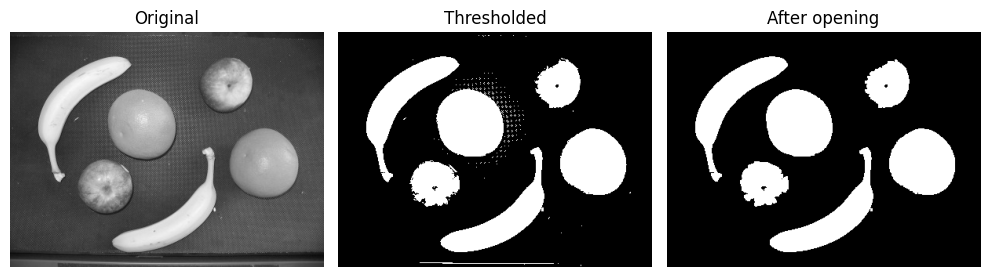

In [3]:
img = cv2.imread('../img/fruit.jpg', cv2.IMREAD_GRAYSCALE)
_, im_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
im_bin2 = cv2.morphologyEx(im_bin, cv2.MORPH_OPEN, kernel)

fig, axes = plt.subplots(1, 3, figsize=(10,4))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(im_bin, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Thresholded')
axes[1].axis('off')
axes[2].imshow(im_bin2, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('After opening')
axes[2].axis('off')
plt.tight_layout()
plt.show()

<p class="image-attribution">Image source: Stan Birchfield</p>

## Flood fill from a seed point

Flood fill starts at a seed pixel and spreads outward to all connected pixels within a tolerance of the seed value, painting them a new color. The classic algorithm keeps a "frontier" of pixels still to visit (implemented as a stack or queue): Pop a pixel; if it's foreground and not yet filled, mark it filled and push its 4-connected neighbors onto the stack. Repeat until the stack is empty, at which point every pixel reachable from the seed by a path of foreground pixels has been found.

In [4]:
def flood_fill_stack(binary, seed):
    """Classic flood fill: an explicit stack holds the frontier of pixels still to visit."""
    filled = np.zeros_like(binary, dtype=bool)
    h, w = binary.shape
    stack = [seed]
    while stack:
        x, y = stack.pop()
        if x < 0 or x >= w or y < 0 or y >= h:
            continue
        if filled[y, x] or binary[y, x] == 0:
            continue
        filled[y, x] = True
        stack.extend([(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)])  # 4-connected neighbors
    return filled

Here we seed the algorithm with a pixel inside the first banana.

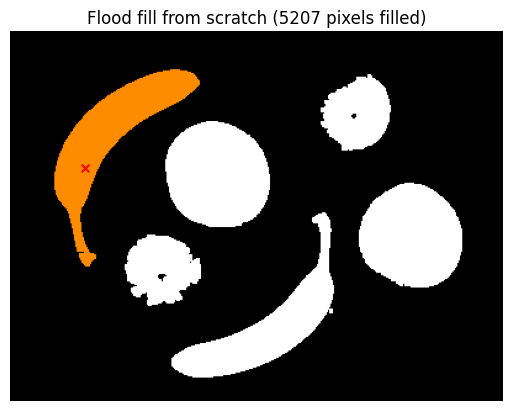

In [5]:
seed = (60, 110)  # (x, y) inside the first banana
im_region_filled = flood_fill_stack(im_bin2, seed)

im_filled = cv2.cvtColor(im_bin2, cv2.COLOR_GRAY2RGB)
im_filled[im_region_filled] = (255, 140, 0)

plt.imshow(im_filled)
plt.scatter(*seed, c='red', s=30, marker='x')
plt.title(f'Flood fill from scratch ({im_region_filled.sum()} pixels filled)')
plt.axis('off')
plt.show()

## Flood fill from a seed point

`cv2.floodFill` does exactly the same thing, just considerably faster because it is compiled.

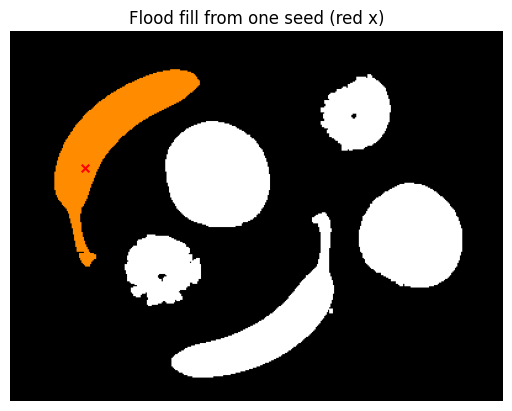

The two implementations match exactly: True


In [6]:
# floodFill needs a mask 2 pixels larger than the image, and modifies the image in place
im_filled_cv2 = cv2.cvtColor(im_bin2, cv2.COLOR_GRAY2RGB)
im_mask = np.zeros(np.add(im_bin2.shape, (2, 2)), dtype=np.uint8)

cv2.floodFill(im_filled_cv2, im_mask, seed, (255, 140, 0))

plt.imshow(im_filled_cv2)
plt.scatter(*seed, c='red', s=30, marker='x')
plt.title('Flood fill from one seed (red x)')
plt.axis('off')
plt.show()

im_region_filled_cv2 = np.all(im_filled_cv2 == (255, 140, 0), axis=-1)
print(f'The two implementations match exactly: {np.array_equal(im_region_filled, im_region_filled_cv2)}')

## Connected components: label every blob at once

Instead of picking seeds by hand, the connected-component labeling algorithm (`cv2.connectedComponentsWithStats`) scans the whole image and assigns every blob its own integer label. (The classic algorithm, which is omitted for brevity, is known as *union-find*, and it requires two passes through the image, as well a traversal of the equivalence table.)

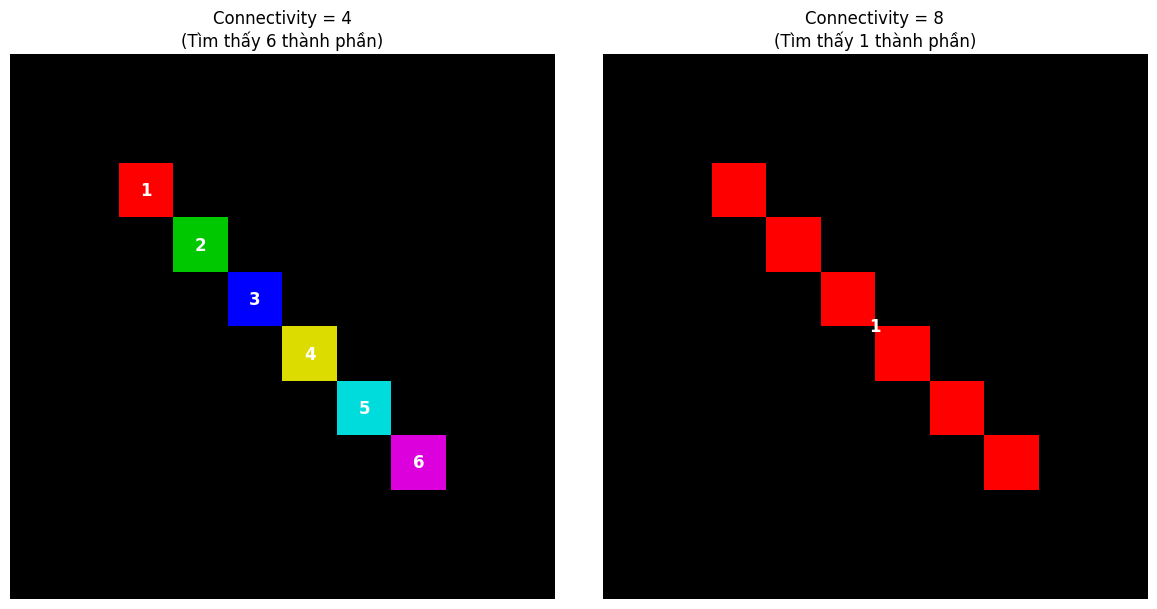

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo ảnh nhị phân chứa đường chéo các điểm ảnh (diagonal staircase)
# Kích thước 10x10, nền đen (0)
im_bin2 = np.zeros((10, 10), dtype=np.uint8)

# Vẽ đường chéo màu trắng (255)
for i in range(2, 8):
    im_bin2[i, i] = 255

# bảng màu ngẫu nhiên/cố định đủ dùng cho các label
colors = np.array([
    [0, 0, 0],         # Label 0: Nền (Đen)
    [255, 0, 0],       # Label 1: Đỏ
    [0, 200, 0],       # Label 2: Xanh lá
    [0, 0, 255],       # Label 3: Xanh dương
    [220, 220, 0],     # Label 4: Vàng
    [0, 220, 220],     # Label 5: Cyan
    [220, 0, 220],     # Label 6: Magenta
    [255, 128, 0],     # Label 7: Cam
    [128, 0, 255]      # Label 8: Tím
])

# 2. Xử lý kết nối Connectivity = 4 và Connectivity = 8
connectivities = [4, 8]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, conn in zip(axes, connectivities):
    # Phân tích thành phần liên thông
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        im_bin2, connectivity=conn
    )

    # Tô màu các label
    im_colored = colors[labels % len(colors)].astype(np.uint8)

    # Hiển thị ảnh
    ax.imshow(im_colored)

    # Đánh số Label tại vị trí Tâm (Centroid)
    for label in range(1, num_labels):
        cx, cy = centroids[label]
        ax.text(cx, cy, str(label), color='white', ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_title(f'Connectivity = {conn}\n(Tìm thấy {num_labels - 1} thành phần)', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

The connected-component labeling algorithm also returns handy stats (e.g., bounding box, area, centroid). This additional information is essentially free, as it requires almost no extra computation (as we will see in Lesson 5).

In [8]:
print(f'Found {num_labels - 1} blobs (plus the background as label 0)\n')
print(f'{"label":>5} {"area":>6} {"centroid":>16}')
for label in range(1, num_labels):
    area = stats[label, cv2.CC_STAT_AREA]
    cx, cy = centroids[label]
    print(f'{label:>5} {area:>6} ({cx:6.1f}, {cy:6.1f})')

Found 6 blobs (plus the background as label 0)

label   area         centroid
    1   5207 (  81.5,   86.1)
    2   2496 ( 281.5,   66.6)
    3   5829 ( 167.9,  116.3)
    4   5545 ( 325.3,  166.1)
    5   4935 ( 209.1,  238.3)
    6   2543 ( 122.3,  192.5)


## Filtering blobs by size

A common use of connected components is to discard small, noise-like blobs and keep only significant ones. Here we choose a threshold that removes the small apples (blobs 2 and 6).

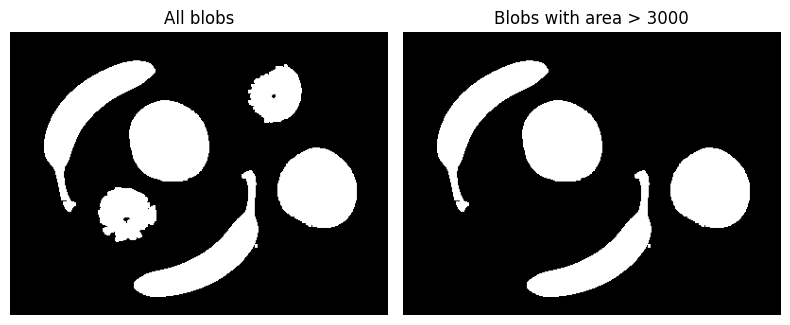

In [9]:
min_area = 3000
img_minsize = np.zeros_like(im_bin2)
for label in range(1, num_labels):
    if stats[label, cv2.CC_STAT_AREA] > min_area:
        img_minsize[labels == label] = 255

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(im_bin2, cmap='gray')
axes[0].set_title('All blobs')
axes[0].axis('off')
axes[1].imshow(img_minsize, cmap='gray')
axes[1].set_title(f'Blobs with area > {min_area}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

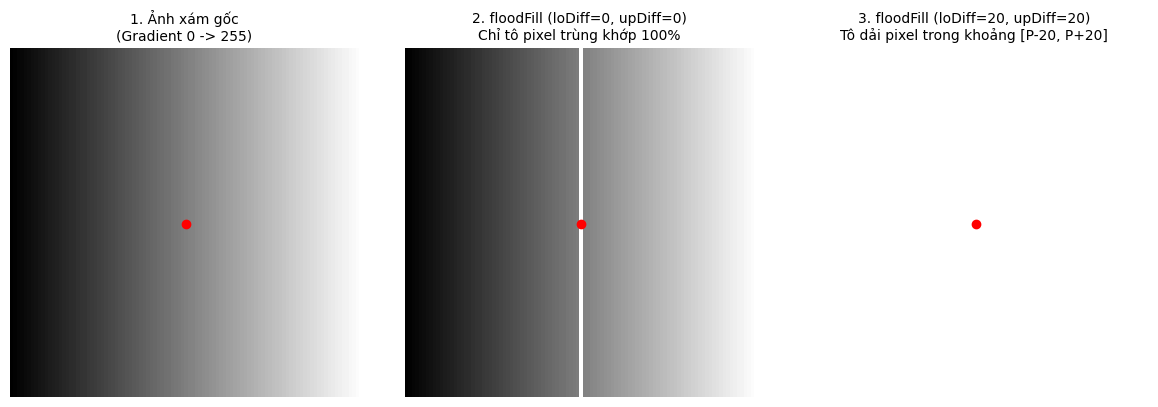

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo một ảnh xám (grayscale) có dải màu xám biến thiên mượt mà (gradient)
gray_img = np.zeros((100, 100), dtype=np.uint8)
for i in range(100):
    gray_img[:, i] = int(i * 2.55)  # Mức xám tăng dần từ 0 (trái) đến 255 (phải)

# Điểm xuất phát (Seed point) tại trung tâm ảnh
seed_point = (50, 50)  # (x, y) = (50, 50) có giá trị mức xám khoảng 127
new_value = 255        # Màu tô mới (Trắng tinh)

# --- Trường hợp 1: loDiff = 0, upDiff = 0 (Tô chính xác tuyệt đối) ---
img_exact = gray_img.copy()
cv2.floodFill(img_exact, mask=None, seedPoint=seed_point, newVal=new_value,
              loDiff=(0,), upDiff=(0,))

# --- Trường hợp 2: loDiff = 20, upDiff = 20 (Có dung sai / Tolerance) ---
img_tol = gray_img.copy()
cv2.floodFill(img_tol, mask=None, seedPoint=seed_point, newVal=new_value,
              loDiff=(20,), upDiff=(20,))

# --- Hiển thị so sánh ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
images = [gray_img, img_exact, img_tol]
titles = [
    '1. Ảnh xám gốc\n(Gradient 0 -> 255)',
    '2. floodFill (loDiff=0, upDiff=0)\nChỉ tô pixel trùng khớp 100%',
    '3. floodFill (loDiff=20, upDiff=20)\nTô dải pixel trong khoảng [P-20, P+20]'
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.plot(seed_point[0], seed_point[1], 'ro') # Đánh dấu điểm Seed
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Exercises

1. Change `connectivity=8` to `connectivity=4` in `connectedComponentsWithStats`. Construct a binary image (e.g., a diagonal staircase of single pixels) where 4-connectivity and 8-connectivity give a *different* number of components.
2. Use `cv2.floodFill` with a nonzero `loDiff`/`upDiff` tolerance on a grayscale (not binary) image, and describe what changes.